In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import softmax
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.io import loadmat
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN, HDBSCAN
from matplotlib.collections import LineCollection
import scipy.signal as ss

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

from scipy.sparse.csgraph import shortest_path

from collections import defaultdict, Counter
import itertools
import warnings

import nystrom_holmqvist as NH

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Load eye data

In [2]:
date = '20260615'
mat = loadmat(f'D:/Newworld/London_{date}_trial.mat', simplify_cells=True)
beh = pd.DataFrame(mat['data'])
beh = beh[beh.TrialError<2]

beh['Success'] = beh.TrialError==0
beh['Flash'] = beh.target_room==beh.start_room
beh['Trialtype'] = 'Fail'
beh.loc[beh.TrialError==0,'Trialtype'] = 'Success'
beh.loc[beh.target_room==beh.start_room,'Trialtype'] = 'Flash'

In [35]:
all_start_fixations = pd.DataFrame()
all_start_saccades = pd.DataFrame()

for idx in range(len(beh)):

    try:
    
        trace = beh.iloc[idx].eye
        x = trace[:,0]
        y = trace[:,1]
        t = np.arange(len(x))

        result = NH.detect_saccades_NH(x,y)
        fixations = result.fixations.copy()
        fixations.insert(0,'Trial',beh.iloc[idx].Trial)
        all_start_fixations = pd.concat([all_start_fixations,fixations])
        
        saccades = result.saccades.copy()
        saccades.insert(0,'Trial',beh.iloc[idx].Trial)
        all_start_saccades = pd.concat([all_start_saccades,saccades])  
        
    except:
        print('Error')


all_start_fixations['n_fixations'] = (
    all_start_fixations.groupby('Trial')['Trial']
    .transform('size')
)
all_start_fixations = all_start_fixations.merge(beh,on='Trial')
all_start_fixations = all_start_fixations[(np.abs(all_start_fixations.x_mean)<25) & (np.abs(all_start_fixations.y_mean)<25)]

all_start_saccades = all_start_saccades.merge(beh,on='Trial')
all_start_saccades = all_start_saccades[all_start_saccades.v_mean<1000]

Error
Error
Error


C:\Users\Admin\AppData\Local\Temp\ipykernel_4684\3753261594.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_start_saccades = pd.concat([all_start_saccades,saccades])


Error
Error
Error


#### cluster fixations and saccades

In [36]:
def classify_center(fixations, saccades):

    # first using HDBSCAN to cluster hotspots in the fixation
    clusterer = HDBSCAN(
        min_cluster_size=50
    )
    X = fixations[['x_mean','y_mean']].values
    labels = clusterer.fit_predict(X)
    
    fixations['cluster'] = labels
    
    cluster_df = pd.DataFrame()
    cluster_mean = fixations.groupby('cluster')[['x_mean','y_mean']].mean()
    cluster_df = pd.concat([cluster_df,cluster_mean],axis=1)
    cluster_sem = fixations.groupby('cluster')[['x_mean','y_mean']].std().rename(columns={'x_mean':'x_std','y_mean':'y_std'})
    cluster_df = pd.concat([cluster_df,cluster_sem],axis=1)
    cluster_df.reset_index(inplace=True)

    # define center using mean and dispersion of the cluster
    center_cluster = cluster_df[((cluster_df.x_mean**2+cluster_df.y_mean**2)<3**2) & (cluster_df.x_std<3) & (cluster_df.y_std<3)].cluster.values[0]
    fixations['center'] = fixations['cluster']==center_cluster

    center_x, center_y = fixations.query('center')[['x_mean','y_mean']].mean()
    r_fixation = np.sqrt(
        (fixations.query('center').x_mean.values-center_x)**2 +
        (fixations.query('center').y_mean.values-center_y)**2
    )
    radius  = np.percentile(r_fixation, 95)

    # using fixation center cluster to define if saccades on and off are at the center
    saccades['on_center'] = ((saccades.x_on.values-center_x)**2 + (saccades.y_on.values-center_y)**2)< radius**2
    saccades['off_center'] = ((saccades.x_off.values-center_x)**2 + (saccades.y_off.values-center_y)**2)< radius**2
    saccades['direction'] = (np.where(all_start_saccades.on_center, 'center', 'periphery')
                                        + '_to_' +
                                        np.where(all_start_saccades.off_center, 'center', 'periphery'))
    
    return fixations, saccades

<Axes: xlabel='x_mean', ylabel='y_mean'>

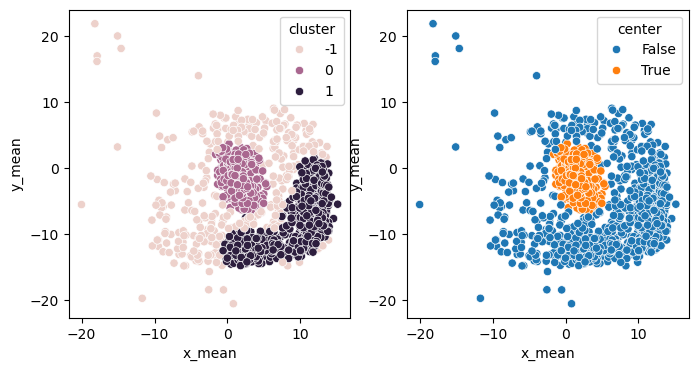

In [6]:
# sanity check center classification
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(8,4))
sns.scatterplot(data=all_start_fixations,x='x_mean',y='y_mean',hue='cluster',ax=axes[0])
sns.scatterplot(data=all_start_fixations,x='x_mean',y='y_mean',hue='center',ax=axes[1])

In [8]:
def cluster_saccades(saccades):
    
    clusterer = HDBSCAN(
        min_cluster_size=50)
    X = saccades[['x_on','y_on','x_off','y_off','distance']].values
    labels = clusterer.fit_predict(X)
    saccades['cluster'] = labels
    
    return saccades

In [37]:
all_start_fixations, all_start_saccades = classify_center(all_start_fixations, all_start_saccades)

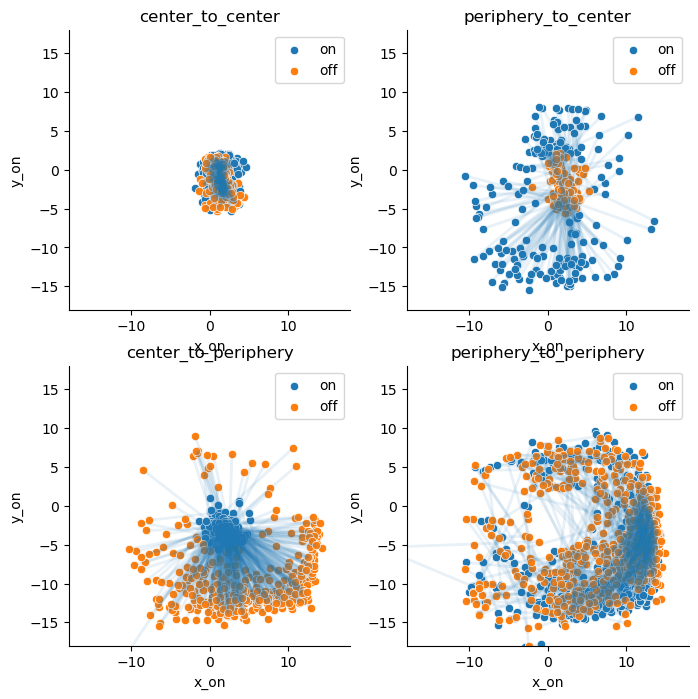

In [46]:
plot_saccades(all_start_saccades)

In [45]:
def plot_saccades(saccades, edge=18):
    
    fig, axes = plt.subplots(2,2,figsize=(8,8))
    
    for n, direction in enumerate(saccades.direction.unique()):
        
        df = saccades.query('direction==@direction')
        segments = np.array([
            [[row.x_on, row.y_on], [row.x_off, row.y_off]]
            for _, row in df.iterrows()
        ])
        
        lc = LineCollection(
            segments,
            alpha=0.1,
            linewidths=2
        )
        
        ax = axes[np.divmod(n,2)]
        ax.add_collection(lc)
        
        sns.scatterplot(data=df, x='x_on', y='y_on', label='on', ax=ax)
        sns.scatterplot(data=df, x='x_off', y='y_off', label='off', ax=ax)
        ax.autoscale()
        ax.set_xlim(-edge,edge)
        ax.set_ylim(-edge,edge)
        ax.set_title(direction)
        
    sns.despine()


In [26]:
res = smf.ols('n_fixations ~ C(Success)', data=all_start_fixations.query('~Flash')).fit()

print(res.summary())
print(res.pvalues)

                            OLS Regression Results                            
Dep. Variable:            n_fixations   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     95.49
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           5.74e-22
Time:                        15:48:56   Log-Likelihood:                -3303.6
No. Observations:                1660   AIC:                             6611.
Df Residuals:                    1658   BIC:                             6622.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              6.5228      0

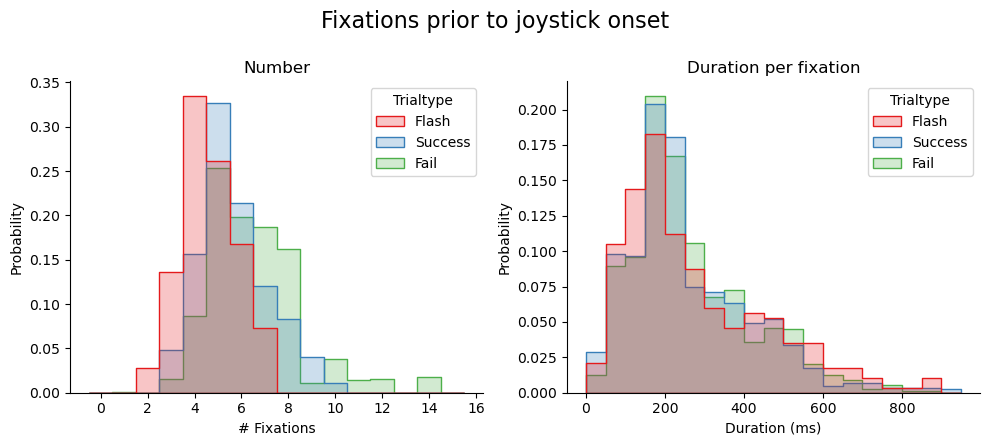

In [67]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4.5))

ax = axes[0]
sns.histplot(data=all_start_fixations,x='n_fixations',hue='Trialtype',bins=np.arange(-0.5,16.5),stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)
ax.set_title('Number')
ax.set_xlabel('# Fixations')

ax = axes[1]
sns.histplot(data=all_start_fixations,x='duration',hue='Trialtype',bins=np.arange(0,1000,50),stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)
ax.set_title('Duration per fixation')
ax.set_xlabel('Duration (ms)')

sns.despine()
plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle('Fixations prior to joystick onset',fontsize=16)
plt.savefig(f'Session {date} fixations prior to joystick onset')

Text(0.5, 0.98, 'Fixations prior to joystick onset')

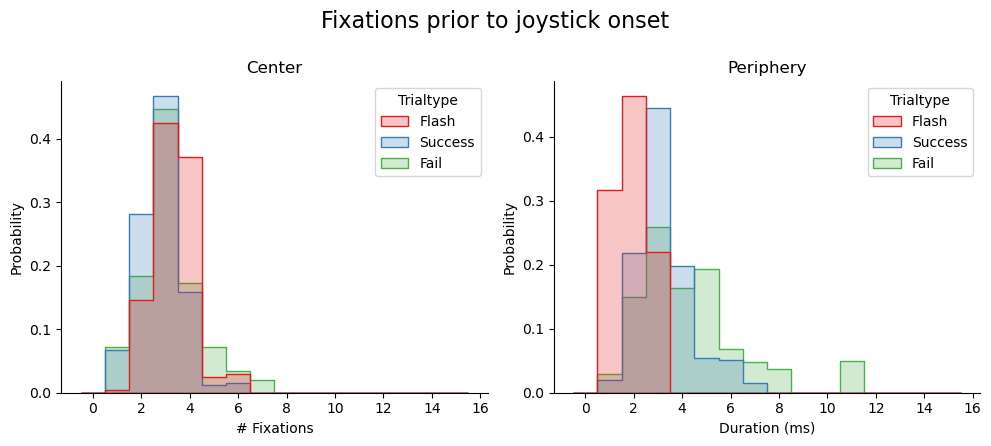

In [77]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4.5))

ax = axes[0]
df = all_start_fixations.query('center').copy()
df['n_fixations'] = df.groupby('Trial')['Trial'].transform('size')
sns.histplot(data=df,x='n_fixations',hue='Trialtype',bins=np.arange(-0.5,16.5),stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)
ax.set_title('Center')
ax.set_xlabel('# Fixations')

ax = axes[1]
df = all_start_fixations.query('~center').copy()
df['n_fixations'] = df.groupby('Trial')['Trial'].transform('size')
sns.histplot(data=df,x='n_fixations',hue='Trialtype',bins=np.arange(-0.5,16.5),stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)
ax.set_title('Periphery')
ax.set_xlabel('# Fixation')

sns.despine()
plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle('Fixations prior to joystick onset',fontsize=16)
# plt.savefig(f'Session {date} fixations prior to joystick onset')

Text(0.5, 0.98, 'Fixations prior to joystick onset')

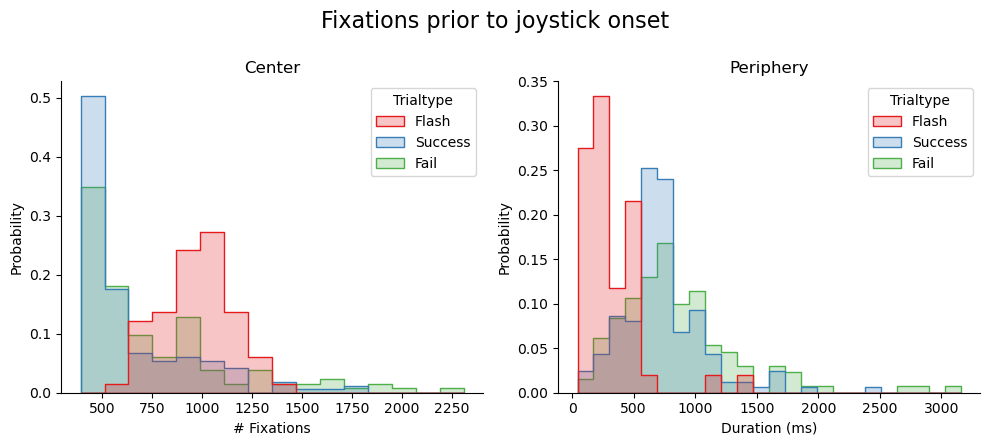

In [78]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4.5))

ax = axes[0]
df = all_start_fixations.query('center').copy().groupby(['Trial','Trialtype']).sum()
sns.histplot(data=df,x='duration',hue='Trialtype',stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)
ax.set_title('Center')
ax.set_xlabel('# Fixations')

ax = axes[1]
df = all_start_fixations.query('~center').copy().groupby(['Trial','Trialtype']).sum()
sns.histplot(data=df,x='duration',hue='Trialtype',stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)
ax.set_title('Periphery')
ax.set_xlabel('Duration (ms)')

sns.despine()
plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle('Fixations prior to joystick onset',fontsize=16)
# plt.savefig(f'Session {date} fixations prior to joystick onset')

Text(0.5, 0.98, 'Fixations prior to joystick onset')

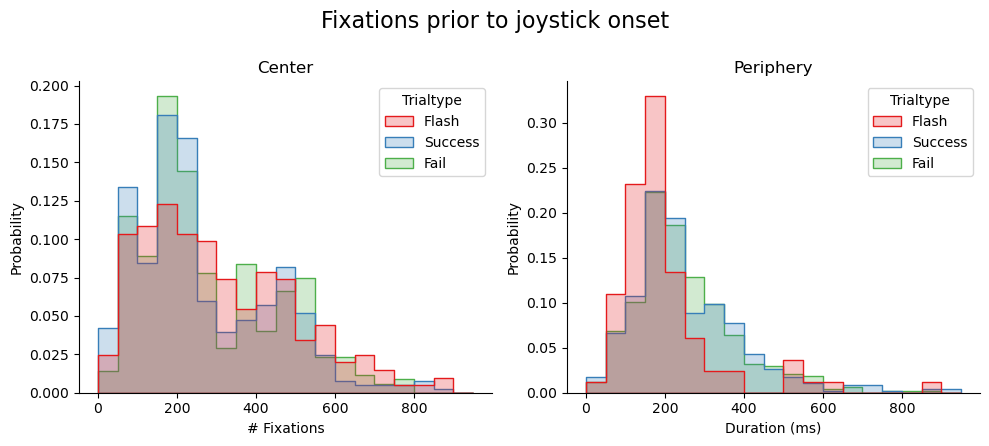

In [79]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4.5))

ax = axes[0]
df = all_start_fixations.query('center').copy()
sns.histplot(data=df,x='duration',hue='Trialtype',bins=np.arange(0,1000,50),stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)
ax.set_title('Center')
ax.set_xlabel('# Fixations')

ax = axes[1]
df = all_start_fixations.query('~center').copy()
sns.histplot(data=df,x='duration',hue='Trialtype',bins=np.arange(0,1000,50),stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)
ax.set_title('Periphery')
ax.set_xlabel('Duration (ms)')

sns.despine()
plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle('Fixations prior to joystick onset',fontsize=16)
# plt.savefig(f'Session {date} fixations prior to joystick onset')

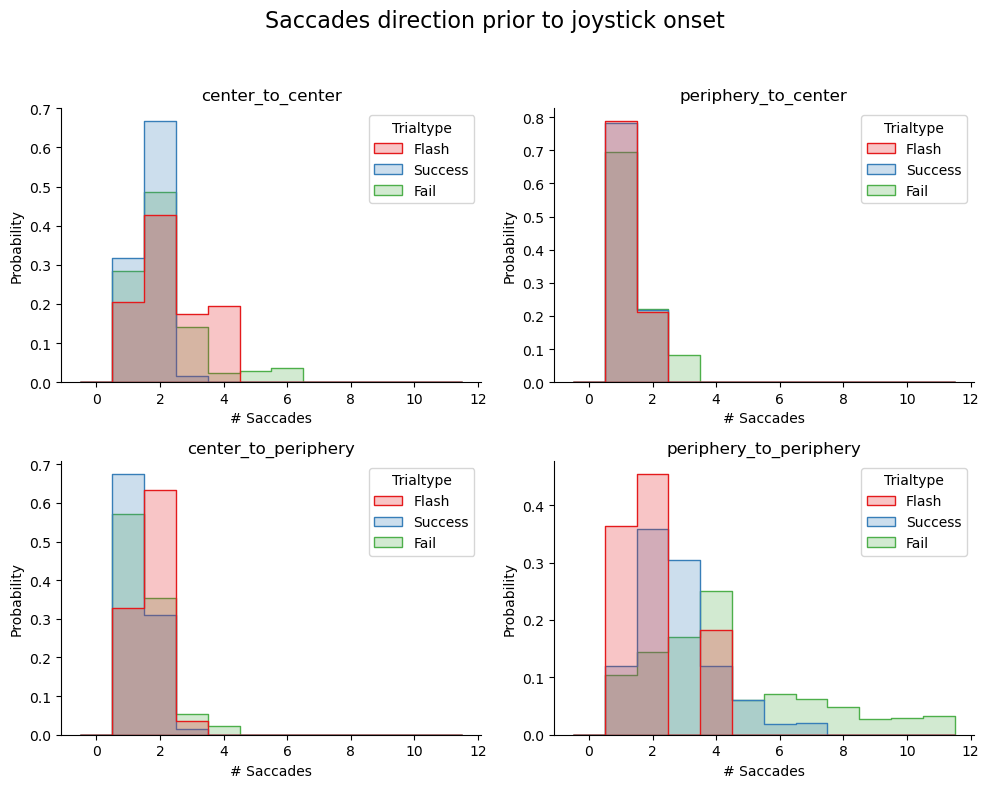

In [80]:
plt.close('all')
fig, axes = plt.subplots(2,2,figsize=(10,8))

for n, direction in enumerate(all_start_saccades.direction.unique()):
    
    df = all_start_saccades.query('direction==@direction').copy()
    df['n_saccades'] = df.groupby('Trial')['Trial'].transform('size')
    ax = axes[np.divmod(n,2)]
            
    sns.histplot(data=df,x='n_saccades',hue='Trialtype',hue_order={'Flash','Success','Fail'},
                 stat='probability',common_norm=False, bins=np.arange(-0.5,12.5),
                 element="step",palette='Set1',ax=ax)
    ax.set_title(direction)
    ax.set_xlabel('# Saccades')


sns.despine()
plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle('Saccades direction prior to joystick onset',fontsize=16)
plt.savefig(f'Session {date} saccades prior to joystick onset')

Text(0.5, 0.98, 'Saccades direction prior to joystick onset')

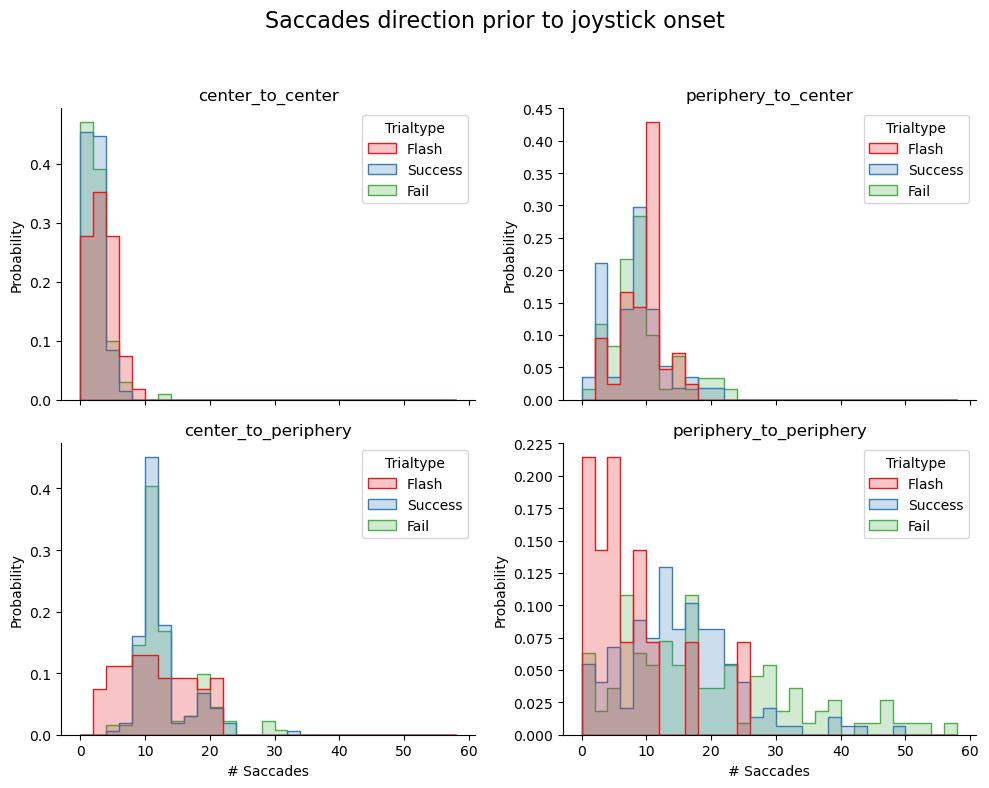

In [85]:
plt.close('all')
fig, axes = plt.subplots(2,2,figsize=(10,8),sharex=True)

for n, direction in enumerate(all_start_saccades.direction.unique()):
    
    df = all_start_saccades.query('direction==@direction').copy().groupby(['Trial','Trialtype']).sum()
    ax = axes[np.divmod(n,2)]
            
    sns.histplot(data=df,x='distance',hue='Trialtype',hue_order={'Flash','Success','Fail'},
                 stat='probability',common_norm=False, bins=np.arange(0,60,2),
                 element="step",palette='Set1',ax=ax)
    ax.set_title(direction)
    ax.set_xlabel('# Saccades')


sns.despine()
plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle('Saccades direction prior to joystick onset',fontsize=16)
# plt.savefig(f'Session {date} saccades prior to joystick onset')

Text(0.5, 0.98, 'Saccades direction prior to joystick onset')

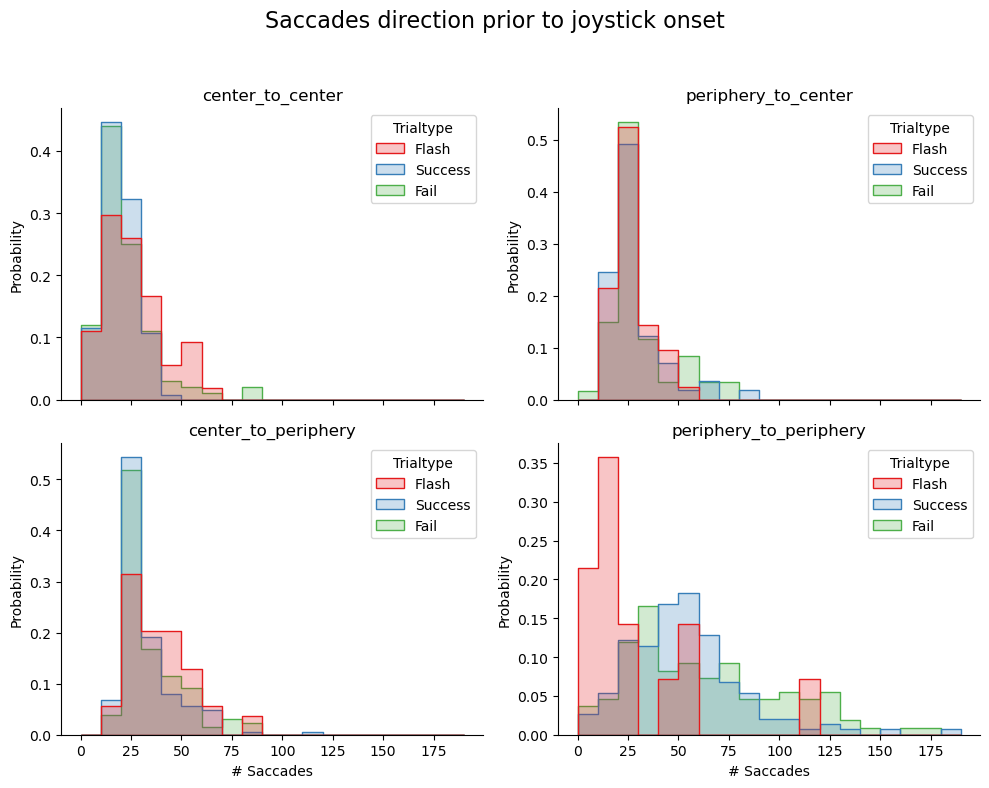

In [87]:
plt.close('all')
fig, axes = plt.subplots(2,2,figsize=(10,8),sharex=True)

for n, direction in enumerate(all_start_saccades.direction.unique()):
    
    df = all_start_saccades.query('direction==@direction').copy().groupby(['Trial','Trialtype']).sum()
    ax = axes[np.divmod(n,2)]
            
    sns.histplot(data=df,x='duration',hue='Trialtype',hue_order={'Flash','Success','Fail'},
                 stat='probability',common_norm=False, bins=np.arange(0,200,10),
                 element="step",palette='Set1',ax=ax)
    ax.set_title(direction)
    ax.set_xlabel('# Saccades')


sns.despine()
plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle('Saccades direction prior to joystick onset',fontsize=16)
# plt.savefig(f'Session {date} saccades prior to joystick onset')

In [58]:
all_start_saccades.columns

Index(['Trial', 't_on', 't_off', 'duration', 'x_on', 'y_on', 'x_off', 'y_off',
       'x_mean', 'y_mean', 'v_peak', 'v_mean', 'distance', 'amplitude',
       'event_type', 'Session', 'BlockNumber', 'InitiatedTrialsInBlock',
       'EngagedTrialsInBlock', 'correctTrialsInBlock', 'instruct',
       'target_room', 'start_room', 'TrialError', 'target_xy', 'start_xy',
       'delta_xy', 'RT', 'graph_distance', 'euclidean_distance',
       'optimal_trajectory', 'actual_trajectory', 'optimality', 'degree',
       'eye', 'joystick', 'Success', 'Flash', 'Trialtype', 'on_center',
       'off_center', 'direction'],
      dtype='object')

Text(0.5, 0.98, 'Saccades direction prior to joystick onset')

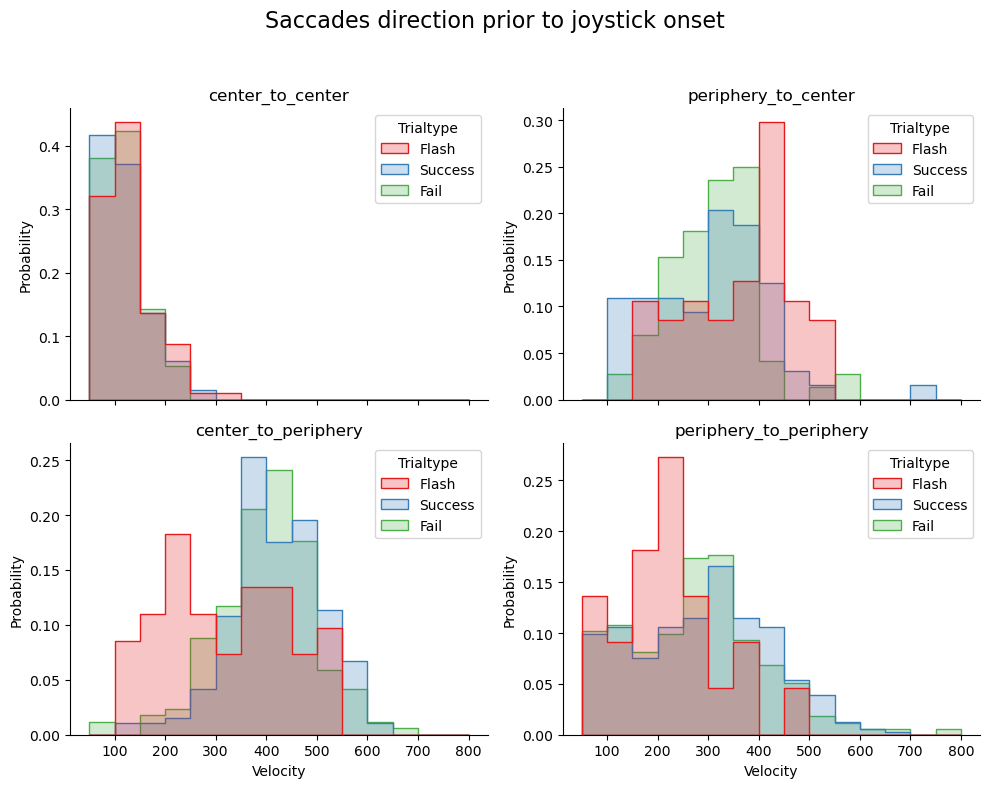

In [66]:
plt.close('all')
fig, axes = plt.subplots(2,2,figsize=(10,8),sharex=True)

for n, direction in enumerate(all_start_saccades.direction.unique()):
    
    df = all_start_saccades.query('direction==@direction').copy()
    df['n_fixations'] = df.groupby('Trial')['Trial'].transform('size')
    ax = axes[np.divmod(n,2)]
            
    sns.histplot(data=df,x='v_mean',hue='Trialtype',hue_order={'Flash','Success','Fail'},
                 stat='probability',common_norm=False, bins=np.arange(50,850,50),
                 element='step',palette='Set1',ax=ax)

    ax.set_title(direction)
    ax.set_xlabel('Velocity')


sns.despine()
plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle('Saccades direction prior to joystick onset',fontsize=16)
# plt.savefig(f'Session {date} saccades prior to joystick onset')

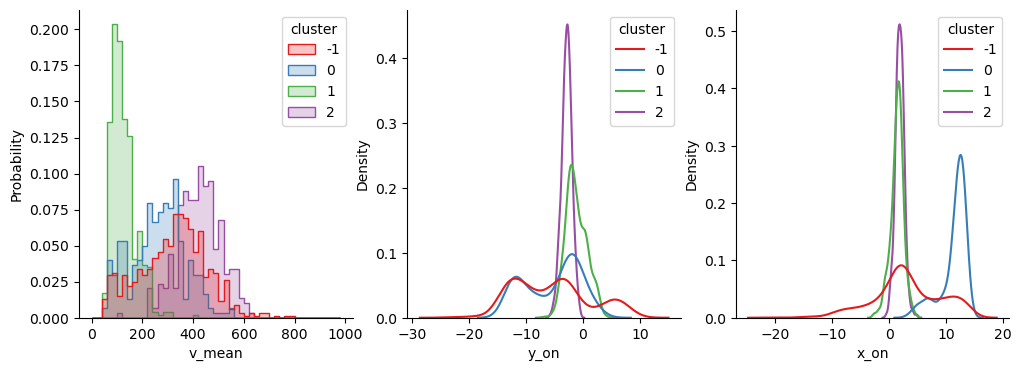

In [272]:
plt.close('all')
fig, axes = plt.subplots(1,3,figsize=(12,4))

ax = axes[0]
# sns.kdeplot(data=all_start_saccades,x='v_mean',hue='Trialtype',common_norm=False,palette='Set1',ax=ax)
sns.histplot(data=all_start_saccades,bins=np.arange(0,1000,20),x='v_mean',hue='cluster',stat='probability',common_norm=False,
           element="step",palette='Set1',ax=ax)

ax = axes[1]
sns.kdeplot(data=all_start_saccades,x='y_on',hue='cluster',common_norm=False,palette='Set1',ax=ax)
# sns.histplot(data=all_start_saccades,bins=np.arange(0,30,2),x='distance',hue='Trialtype',stat='probability',common_norm=False,
#            element="step",palette='Set1',ax=ax)

ax = axes[2]
sns.kdeplot(data=all_start_saccades,x='x_on',hue='cluster',common_norm=False,palette='Set1',ax=ax)


sns.despine()
# plt.title('Number of fixations prior to joystick onset')
# plt.xlabel('# Fixations')
# plt.savefig(f'Session {date} Number of fixations prior to joystick onset')

In [120]:
import os
os.environ["OMP_NUM_THREADS"] = "8"

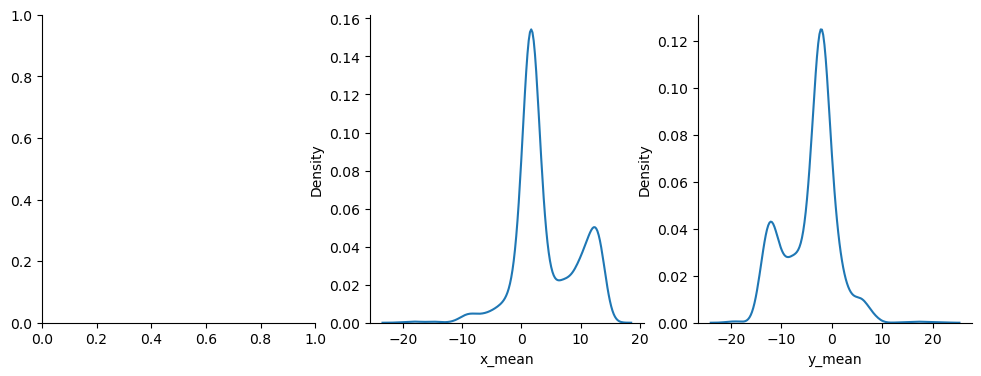

In [126]:
plt.close('all')
fig, axes = plt.subplots(1,3,figsize=(12,4))

ax = axes[0]
# sns.kdeplot(data=all_start_saccades,x='v_mean',hue='Trialtype',common_norm=False,palette='Set1',ax=ax)
# sns.histplot(data=all_start_fixations,bins=np.arange(0,1000,20),x='v_mean',hue='Trialtype',stat='probability',common_norm=False,
#            element="step",palette='Set1',ax=ax)

ax = axes[1]
sns.kdeplot(data=all_start_fixations,x='x_mean',ax=ax)
# sns.histplot(data=all_start_saccades,bins=np.arange(0,30,2),x='distance',hue='Trialtype',stat='probability',common_norm=False,
#            element="step",palette='Set1',ax=ax)

ax = axes[2]
sns.kdeplot(data=all_start_fixations,x='y_mean',ax=ax)


sns.despine()
# plt.title('Number of fixations prior to joystick onset')
# plt.xlabel('# Fixations')
# plt.savefig(f'Session {date} Number of fixations prior to joystick onset')

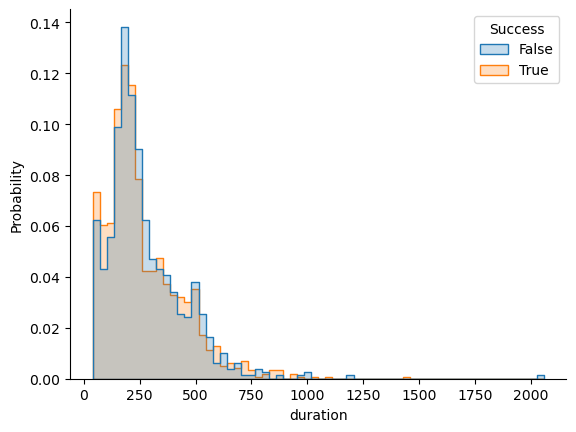

In [12]:
plt.close('all')
sns.histplot(data=all_start_fixations,x='duration',hue='Success',stat='probability',common_norm=False,
           element="step")
sns.despine()
# plt.title('Number of fixations prior to joystick onset')
# plt.xlabel('# Fixations')
# plt.savefig(f'Session {date} Number of fixations prior to joystick onset')

In [162]:
edge=20
all_start_fixations = all_start_fixations[(np.abs(all_start_fixations.x_mean)<edge) & (np.abs(all_start_fixations.y_mean)<edge)]

In [175]:
all_start_fixations['x_mean_corrected'] = all_start_fixations['x_mean']-x_center
all_start_fixations['y_mean_corrected'] = all_start_fixations['y_mean']-y_center

In [182]:
gmm = GaussianMixture(
    n_components=5,
    random_state=0
)
center = gmm.fit_predict(all_start_fixations[['x_mean','y_mean']].values)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


In [196]:
peri_start_fixations = all_start_fixations[(all_start_fixations.x_mean**2+all_start_fixations.y_mean**2)>25]

(np.float64(-24.45406695277384),
 np.float64(19.553742582932536),
 np.float64(-24.917443451310486),
 np.float64(26.215978277650507))

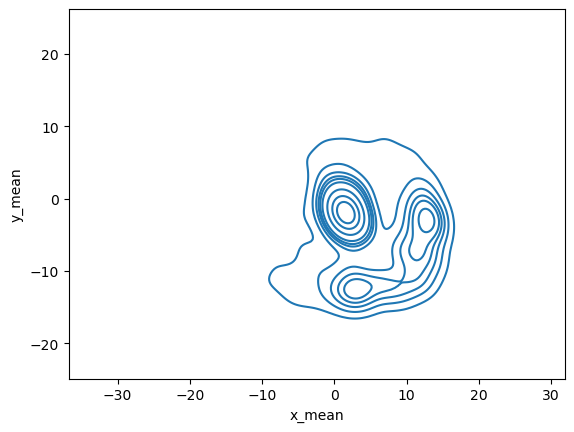

In [174]:
plt.close('all')
sns.kdeplot(data=all_start_fixations,x='x_mean',y='y_mean')
plt.axis('equal')

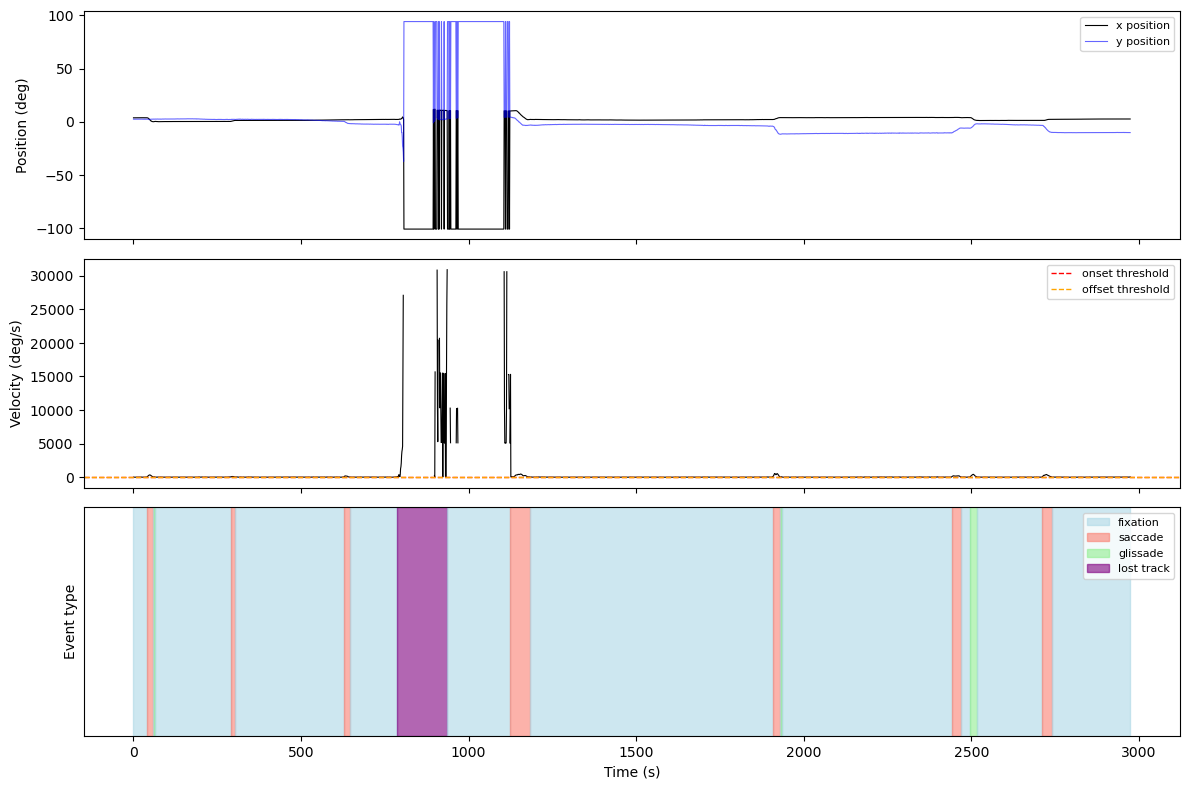

In [159]:
# Plot
plt.close('all')
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, x, 'k', lw=0.8, label='x position')
axes[0].plot(t, y, 'b', lw=0.8, alpha=0.6, label='y position')
axes[0].set_ylabel('Position (deg)')
axes[0].legend(fontsize=8)
# axes[0].set_ylim(-30,30)

axes[1].plot(t, result.velocity, 'k', lw=0.8)
axes[1].axhline(result.threshold_onset,  color='r', ls='--', lw=1, label='onset threshold')
axes[1].axhline(result.threshold_offset, color='orange', ls='--', lw=1, label='offset threshold')
axes[1].set_ylabel('Velocity (deg/s)')
axes[1].legend(fontsize=8)

colors = {0: 'lightblue', 1: 'salmon', 2: 'lightgreen', 3:'purple'}
labels_map = {0: 'fixation', 1: 'saccade', 2: 'glissade', 3:'lost track'}
prev = result.labels[0]
seg_start = 0
for i in range(1, len(result.labels)):
    if result.labels[i] != prev or i == len(result.labels) - 1:
        axes[2].axvspan(t[seg_start], t[i], alpha=0.6,
                        color=colors[prev], label=labels_map[prev])
        seg_start = i
        prev = result.labels[i]

# deduplicate legend
handles, lbls = axes[2].get_legend_handles_labels()
by_label = dict(zip(lbls, handles))
axes[2].legend(by_label.values(), by_label.keys(), fontsize=8)
axes[2].set_ylabel('Event type')
axes[2].set_xlabel('Time (s)')
axes[2].set_yticks([])

plt.tight_layout()
# plt.savefig(f'trial {trial}.png', dpi=150)

(-15.0, 15.0)

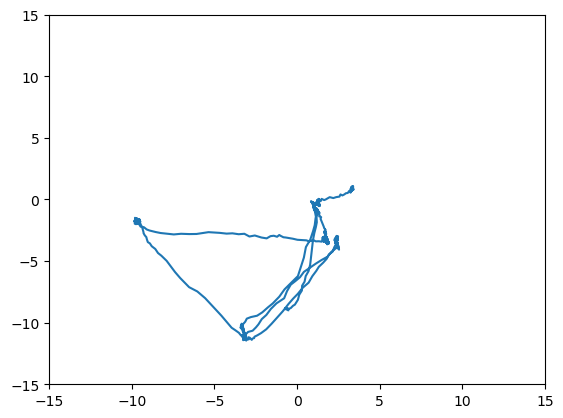

In [126]:
edge = 15
plt.close('all')
plt.plot(x,y)
plt.xlim(-edge,edge)
plt.ylim(-edge,edge)

91 Error


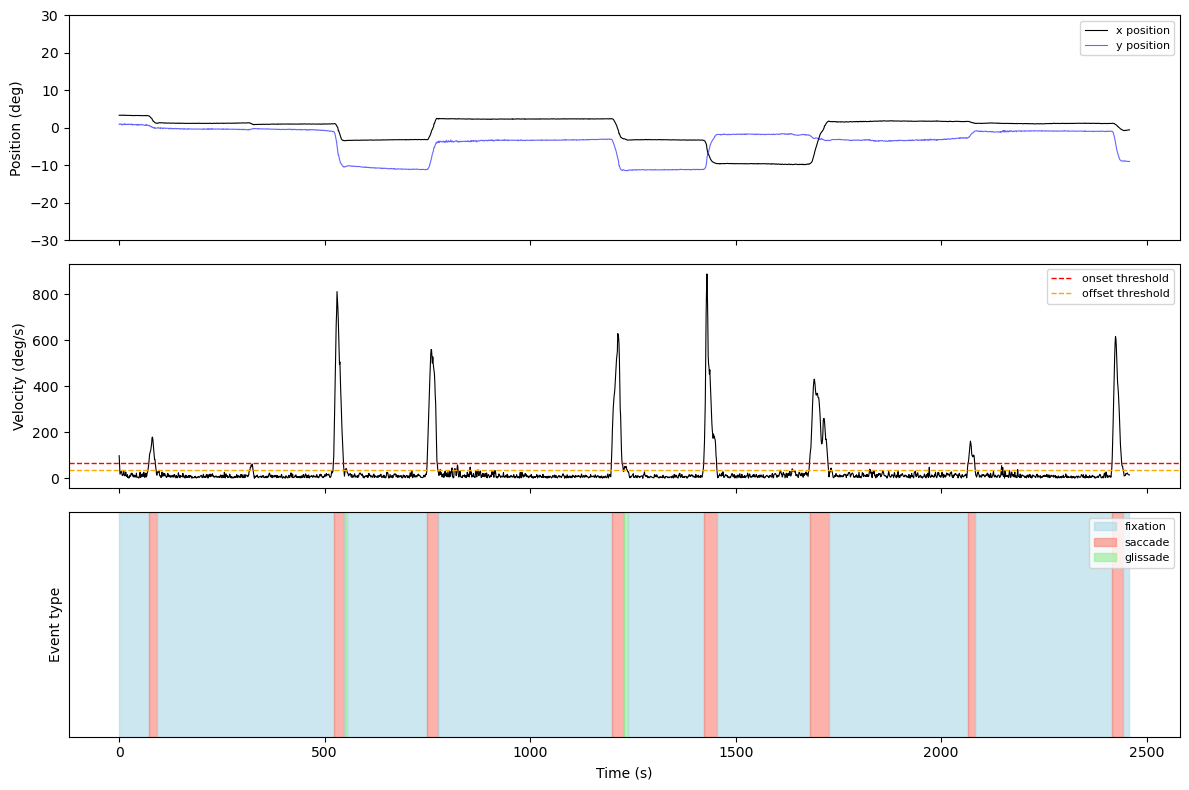

In [120]:
for trial in np.random.choice(np.arange(len(beh)),40):

    try:
    
        trace = beh.iloc[trial].eye
        x = trace[:,0]
        y = trace[:,1]
        t = np.arange(len(x))

        result = NH.detect_saccades_NH(x,y)
        
        # Plot
        plt.close('all')
        fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
        
        axes[0].plot(t, x, 'k', lw=0.8, label='x position')
        axes[0].plot(t, y, 'b', lw=0.8, alpha=0.6, label='y position')
        axes[0].set_ylabel('Position (deg)')
        axes[0].legend(fontsize=8)
        axes[0].set_ylim(-30,30)
        
        axes[1].plot(t, result.velocity, 'k', lw=0.8)
        axes[1].axhline(result.threshold_onset,  color='r', ls='--', lw=1, label='onset threshold')
        axes[1].axhline(result.threshold_offset, color='orange', ls='--', lw=1, label='offset threshold')
        axes[1].set_ylabel('Velocity (deg/s)')
        axes[1].legend(fontsize=8)
        
        colors = {0: 'lightblue', 1: 'salmon', 2: 'lightgreen', 3:'purple'}
        labels_map = {0: 'fixation', 1: 'saccade', 2: 'glissade', 3:'lost track'}
        prev = result.labels[0]
        seg_start = 0
        for i in range(1, len(result.labels)):
            if result.labels[i] != prev or i == len(result.labels) - 1:
                axes[2].axvspan(t[seg_start], t[i], alpha=0.6,
                                color=colors[prev], label=labels_map[prev])
                seg_start = i
                prev = result.labels[i]
        
        # deduplicate legend
        handles, lbls = axes[2].get_legend_handles_labels()
        by_label = dict(zip(lbls, handles))
        axes[2].legend(by_label.values(), by_label.keys(), fontsize=8)
        axes[2].set_ylabel('Event type')
        axes[2].set_xlabel('Time (s)')
        axes[2].set_yticks([])
        
        plt.tight_layout()
        plt.savefig(f'trial {trial}.png', dpi=150)

    except:
        print(trial, 'Error')